## Le chiffrement 

In [6]:
# soit p l'information originale en binaire 
# soit g un flux de clé (binaire) 
def chiff(p,g): 
    c=[]
    for i in range(len(p)):
        if p[i]== g[i]:
            c.append(0)
        else: c.append(1) 
    return c

In [12]:

def texte_vers_bits(texte):
    bits = []
    for c in texte:
        octet = format(ord(c), '08b') 
        bits.extend([int(bit) for bit in octet])  
    return bits
def bits_vers_texte(bits):
    return ''.join([chr(int(''.join(map(str, bits[i:i+8])), 2)) for i in range(0, len(bits), 8)])
texte= 'TIPE'
g= [0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0]
p= texte_vers_bits(texte)
c=  chiff(p,g)
print( bits_vers_texte(c),c)


NLVI [0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]


## Le déchiffrement 

In [20]:
# soit c l'information chiffrée en binaire 
# soit g un flux de clé (binaire) généré par le générateur G initialisé par la clé K
def dechiff(c,g): 
    p=[]
    for i in range(len(c)):
        if c[i]== g[i]:
            p.append(0)
        else: p.append(1) 
    return p
      

In [21]:
g= [0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0]
#on a d'après le fonction de chiffremnt:
c= [0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]
p_1=dechiff(c,g)
print(bits_vers_texte(p_1))

TIPE


## LCG

In [31]:
def lcg(M,a,c,m,K):
    L=[]
    b=K
    for i in range (M):
        L.append(b%2)
        b=(a*b+c)%m
    return L

In [32]:
lcg(26,2,5,7,45)

[1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0]

## BBS


In [46]:
def bbs(M, K, p, q):
    L = []
    N = p * q
    x = K  
    for i in range(M):
        x = (x ** 2) % N  
        L.append(x % 2)    
    return L

In [47]:
bbs(26,5,11,7)

[1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]

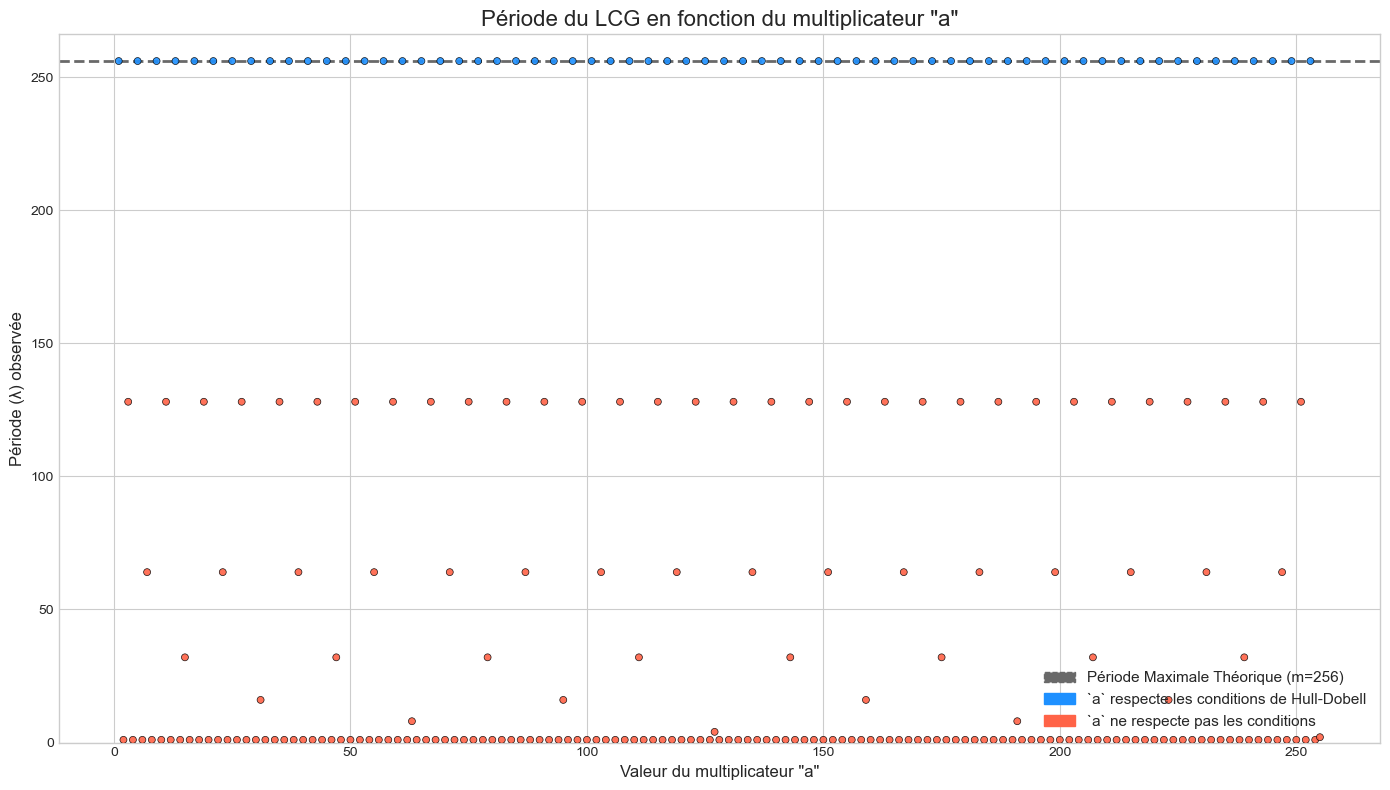

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def pgcd(a, b):
    while b:
        a, b = b, a % b
    return a
def trouver_facteurs_premiers(n):
    facteurs = set()
    d = 2
    temp = n
    while d * d <= temp:
        if temp % d == 0:
            facteurs.add(d)
            while temp % d == 0:
                temp //= d
        d += 1
    if temp > 1:
        facteurs.add(temp)
    return facteurs
def verifier_conditions_hull_dobell(a, c, m):
    if pgcd(c, m) != 1: return False
    for p in trouver_facteurs_premiers(m):
        if (a - 1) % p != 0: return False
    if m % 4 == 0:
        if (a - 1) % 4 != 0: return False
    return True

def detecter_cycle(fonction, valeur_initiale):
    tortue = fonction(valeur_initiale)
    lievre = fonction(fonction(valeur_initiale))
    while tortue != lievre:
        tortue = fonction(tortue)
        lievre = fonction(fonction(lievre)) 
    longueur_cycle = 1
    lievre = fonction(tortue)
    while tortue != lievre:
        lievre = fonction(lievre)
        longueur_cycle += 1
    return longueur_cycle

# --- Script Principal pour la génération du graphique ---


MODULE = 256
INCREMENT = 1
valeurs_a = []
periodes_observees = []
couleurs_points = []
for a in range(1, MODULE):
    fonction_lcg = lambda x: (a * x + INCREMENT) % MODULE
    periode = detecter_cycle(fonction_lcg, 0)
    respecte_theorie = verifier_conditions_hull_dobell(a, INCREMENT, MODULE)
    valeurs_a.append(a)
    periodes_observees.append(periode)
    couleurs_points.append('dodgerblue' if respecte_theorie else 'tomato')
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(valeurs_a, periodes_observees, c=couleurs_points)
ax.axhline(y=MODULE, color='black', linestyle='--', linewidth=2)
ax.set_title('Période du LCG en fonction du multiplicateur "a"')
ax.set_xlabel('Valeur du multiplicateur "a"')
ax.set_ylabel('Période (λ) observée')
ax.set_ylim(0, MODULE + 10)
legende_theorique = mpatches.Patch(color='black', linestyle='--', label=f'Période Maximale Théorique (m={MODULE})')
legende_bleu = mpatches.Patch(color='blue', label='`a` respecte les conditions de Hull-Dobell')
legende_rouge = mpatches.Patch(color='red', label='`a` ne respecte pas les conditions')
ax.legend(handles=[legende_theorique, legende_bleu, legende_rouge], loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
import math
def pgcd(a, b):
    while b:
        a, b = b, a % b
    return a
def ppcm(a, b):
    return (a * b) // pgcd(a, b) if a != 0 and b != 0 else 0
def trouver_facteurs_premiers(n):
    facteurs = {}
    d = 2
    temp = n
    while d * d <= temp:
        while temp % d == 0:
            facteurs[d] = facteurs.get(d, 0) + 1
            temp //= d
        d += 1
    if temp > 1:
        facteurs[temp] = facteurs.get(temp, 0) + 1
    return facteurs
def fonction_carmichael(n):
    if n == 1: return 1
    facteurs = trouver_facteurs_premiers(n)
    valeurs_a_combiner = []
    for p, k in facteurs.items():
        if p == 2 and k >= 3:
            valeurs_a_combiner.append(2**(k - 2))
        else:
            valeurs_a_combiner.append((p - 1) * (p**(k - 1)))
    resultat = 1
    for valeur in valeurs_a_combiner:
        resultat = ppcm(resultat, valeur)
    return resultat
def detecter_cycle_floyd(fonction, valeur_initiale):
    tortue = fonction(valeur_initiale)
    lievre = fonction(fonction(valeur_initiale))
    while tortue != lievre:
        tortue = fonction(tortue)
        lievre = fonction(fonction(lievre))
    longueur_cycle = 1
    lievre = fonction(tortue)
    while tortue != lievre:
        lievre = fonction(lievre)
        longueur_cycle += 1
    return longueur_cycle


    p_test = 11
    q_test = 19
    graine_test = 3
    N_test = p_test * q_test
    print(f"Générateur BBS initialisé avec N = {p_test}*{q_test} = {N_test} et graine = {graine_test}\n")
    # --- Étape 1 : Calcul Théorique ---
    print("--- Étape 1 : Calcul Théorique ---")
    lambda_N = fonction_carmichael(N_test)
    periode_theorique_max = fonction_carmichael(lambda_N)
    print(f"La période attendue est un diviseur de λ(λ(N)) = λ({lambda_N}) = {periode_theorique_max}.")
    # --- Étape 2 : Mesure Expérimentale ---
    print("\n--- Étape 2 : Mesure Expérimentale ---")
    fonction_de_transition = lambda x: pow(x, 2, N_test)
    periode_reelle = detecter_cycle_floyd(fonction_de_transition, graine_test)
    print(f"Période réelle observée avec l'algorithme de Floyd : λ = {periode_reelle}")
    # --- Étape 3 : Conclusion ---
    print("\n--- Étape 3 : Conclusion ---")
    if periode_theorique_max % periode_reelle == 0:
        print(f"SUCCÈS : L'expérience confirme parfaitement la théorie.")
        print(f"La période mesurée ({periode_reelle}) divise de la valeur max théorique ({periode_theorique_max}).")
    else:
        print(f"ÉCHEC : La théorie n'est pas vérifiée.")

--- DÉMONSTRATION : Vérification de la Théorie de la Période de BBS ---

Générateur BBS initialisé avec N = 11*19 = 209 et graine = 3

--- Étape 1 : Calcul Théorique ---
La période attendue est un diviseur de λ(λ(N)) = λ(90) = 12.

--- Étape 2 : Mesure Expérimentale ---
Période réelle observée avec l'algorithme de Floyd : λ = 12

--- Étape 3 : Conclusion ---
SUCCÈS : L'expérience confirme parfaitement la théorie.
La période mesurée (12) est bien un diviseur de la valeur maximale théorique (12).


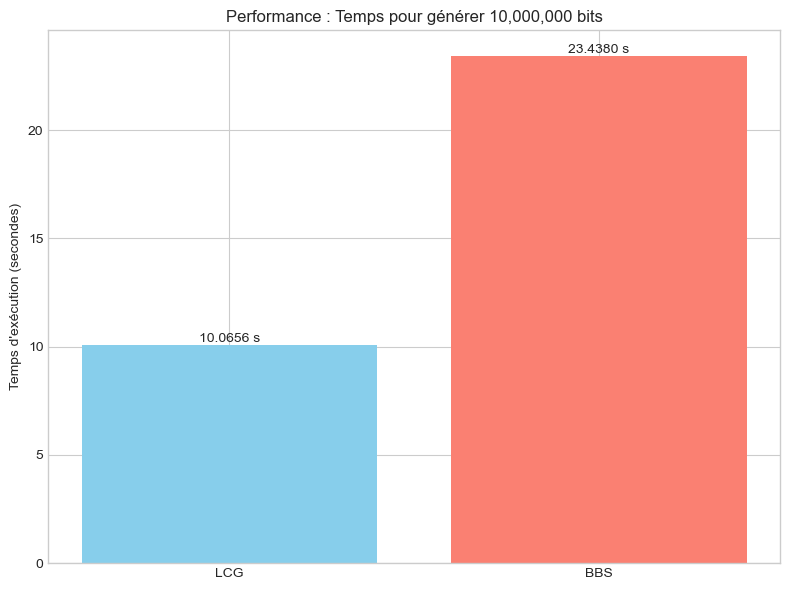

In [8]:
import time
import random
import matplotlib.pyplot as plt

def est_premier_miller_rabin(n, k=20):
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0: return False
    s, t = 0, n - 1
    while t % 2 == 0:
        s += 1
        t //= 2
    for _ in range(k):
        a = random.randrange(2, n - 1)
        x = pow(a, t, n)
        if x == 1 or x == n - 1:
            continue
        for _ in range(s - 1):
            x = pow(x, 2, n)
            if x == n - 1:
                break
        else:
            return False
    return True
def generer_premier_blum(nb_bits):
    while True:
        p = random.getrandbits(nb_bits)
        p |= (1 << (nb_bits - 1)) | 1
        if p % 4 == 3 and est_premier_miller_rabin(p):
            return p
def etape_lcg(etat_actuel, a, c, m):
    etat_suivant = (a * etat_actuel + c) % m
    bit_genere = etat_suivant & 1
    return etat_suivant, bit_genere
def etape_bbs(etat_actuel, N):
    etat_suivant = pow(etat_actuel, 2, N)
    bit_genere = etat_suivant % 2
    return etat_suivant, bit_genere

NB_BITS_A_GENERER = 10000000
a_lcg = 1103515245
c_lcg = 12345
m_lcg = 2**31
etat_courant_lcg = int(time.time())
debut_lcg = time.perf_counter()
for _ in range(NB_BITS_A_GENERER):
    etat_courant_lcg, _ = etape_lcg(etat_courant_lcg, a_lcg, c_lcg, m_lcg)
fin_lcg = time.perf_counter()
temps_lcg = fin_lcg - debut_lcg
p_bbs = generer_premier_blum(256)
q_bbs = generer_premier_blum(256)
N_bbs = p_bbs * q_bbs
etat_courant_bbs = random.randint(3, N_bbs - 1)
debut_bbs = time.perf_counter()
for _ in range(NB_BITS_A_GENERER):
    etat_courant_bbs, _ = etape_bbs(etat_courant_bbs, N_bbs)
fin_bbs = time.perf_counter()
temps_bbs = fin_bbs - debut_bbs
etiquettes = ['LCG', 'BBS']
temps = [temps_lcg, temps_bbs]
couleurs = ['blue', 'red']
fig, ax = plt.subplots(figsize=(8, 6))
barres = ax.bar(etiquettes, temps, color=couleurs)
ax.set_ylabel("Temps d'exécution (secondes)")
ax.set_title(f"Performance : Temps pour générer {NB_BITS_A_GENERER:,} bits")
ax.set_ylim(bottom=0)
for barre in barres:
    hauteur = barre.get_height()
    ax.text(barre.get_x() + barre.get_width() / 2, hauteur, f'{hauteur:.4f} s', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [11]:

def effectuer_test_khi_deux(nom_generateur, fonction_etape, etat_initial, args_fonction, nb_paires):
    print(f"\n--- Test statistique pour : {nom_generateur} ---")
    etat = etat_initial
    comptages = {'00': 0, '01': 0, '10': 0, '11': 0}
    for _ in range(nb_paires):
        etat, bit1 = fonction_etape(etat, *args_fonction)
        etat, bit2 = fonction_etape(etat, *args_fonction)
        paire = f"{bit1}{bit2}"
        comptages[paire] += 1
    valeur_attendue = nb_paires / 4
    khi_deux = sum([(compte - valeur_attendue)**2 / valeur_attendue for compte in comptages.values()])
    print(f"pour {nb_paires//1000}k paires :")
    print(f"  • '00': {comptages['00']:<7} | '01': {comptages['01']}")
    print(f"  • '10': {comptages['10']:<7} | '11': {comptages['11']}")
    print(f"(Attendu : {int(valeur_attendue)} pour chaque) Calcul : χ² ≈ {khi_deux:.2f}.")
    SEUIL_NIST = 7.81
    if khi_deux > SEUIL_NIST:
        print(f"Verdict : Comme {khi_deux:.2f} > {SEUIL_NIST}, on rejette H.")
        print(f"Les bits du {nom_generateur} ne sont pas indépendants.")
    else:
        print(f"Verdict : Comme {khi_deux:.2f} < {SEUIL_NIST}, H n'est pas rejetée.")
        print(f"Le {nom_generateur} passe le test d'indépendance.")
    
NB_PAIRES_TEST = 500_000
params_lcg = (65539, 0, 2**31) 
etat_initial_lcg = int(time.time())
effectuer_test_khi_deux("LCG", etape_lcg, etat_initial_lcg, params_lcg, NB_PAIRES_TEST)
p = generer_premier_blum(256)
q = generer_premier_blum(256)
N_bbs = p * q
params_bbs = (N_bbs,)
etat_initial_bbs = random.randint(3, N_bbs - 1) 
effectuer_test_khi_deux("BBS", etape_bbs, etat_initial_bbs, params_bbs, NB_PAIRES_TEST)
 


--- Test statistique pour : LCG ---
pour 500k paires :
  • '00': 500000  | '01': 0
  • '10': 0       | '11': 0
(Attendu : 125000 pour chaque) Calcul : χ² ≈ 1500000.00.
Verdict : Comme 1500000.00 > 7.81, on rejette H.
Les bits du LCG ne sont pas indépendants.

--- Test statistique pour : BBS ---
pour 500k paires :
  • '00': 124948  | '01': 125010
  • '10': 125196  | '11': 124846
(Attendu : 125000 pour chaque) Calcul : χ² ≈ 0.52.
Verdict : Comme 0.52 < 7.81, H n'est pas rejetée.
Le BBS passe le test d'indépendance.
